In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

db_path = Path("../data/crypto_data_cleaned.db")
conn = sqlite3.connect(str(db_path))

In [4]:
#Overview TOP 10
query = """
SELECT *
FROM crypto_prices_cleaned
WHERE date = (SELECT MAX(date) FROM crypto_prices_cleaned)
GROUP BY symbol
ORDER BY current_price DESC
LIMIT 10;
"""

df = pd.read_sql(query, conn)


df

,name,symbol,current_price,market_cap,market_cap_rank,total_volume,price_change_24h,price_change_7d,price_change_30d,date
0,Bitcoin,BTC,67728.00,1354193732696,1,3.197932e+10,1.60453,-0.126809,7.203079,2026-03-30
1,PAX Gold,PAXG,4537.89,2332852568,39,2.359575e+08,1.00524,6.911137,-15.150958,2026-03-30
2,Tether Gold,XAUT,4529.45,2534564917,38,4.441439e+08,1.00516,6.495516,-14.750419,2026-03-30
3,Ethereum,ETH,2065.20,249147393793,2,1.442113e+10,3.13461,1.445186,12.160706,2026-03-30
4,BNB,BNB,620.22,84537137006,4,8.908953e+08,1.07183,-0.355748,4.717902,2026-03-30
5,Bitcoin Cash,BCH,453.49,9081817523,15,4.117764e+08,-6.20035,-2.357296,2.041791,2026-03-30
6,Monero,XMR,337.22,6217428056,18,7.268632e+07,3.23510,-5.618360,1.968959,2026-03-30
7,Bittensor,TAO,317.49,3046629485,33,3.378490e+08,-0.46984,17.636655,85.876210,2026-03-30
8,Zcash,ZEC,230.00,3822574968,30,2.769468e+08,5.85737,4.837494,12.030326,2026-03-30
9,OKB,OKB,85.08,1786785835,45,1.495168e+07,-0.55696,1.837372,15.607456,2026-03-30


In [5]:
#Top 10 by market cap in mlns ranking
top_market_cap_query = """
SELECT name, 
symbol, 
current_price, 
(market_cap/1000000) AS market_cap_mln, 
(total_volume/1000000) AS total_volume_mln
FROM crypto_prices_cleaned
WHERE date = (SELECT MAX(date) FROM crypto_prices_cleaned)
ORDER BY market_cap_mln DESC
LIMIT 10;
"""

top_market_cap_df = pd.read_sql(top_market_cap_query, conn)
top_market_cap_df

,name,symbol,current_price,market_cap_mln,total_volume_mln
0,Bitcoin,BTC,67728.000000,1354193,31979.322795
1,Ethereum,ETH,2065.200000,249147,14421.125217
2,Tether,USDT,0.999178,184064,49535.209247
3,BNB,BNB,620.220000,84537,890.895313
4,XRP,XRP,1.360000,83491,1770.443535
5,USDC,USDC,0.999816,77665,6794.843454
6,Solana,SOL,84.490000,48347,2893.147313
7,TRON,TRX,0.321699,30486,629.556387
8,Figure Heloc,FIGR_HELOC,1.019000,16560,1.400009
9,Dogecoin,DOGE,0.093343,14342,1056.159320


In [6]:
#TOP 10 Coins that gained the most in the last 24h in %
top_gainers_24h_query = """
SELECT name, 
symbol, 
current_price, 
price_change_24h,
price_change_7d,
price_change_30d
FROM crypto_prices_cleaned
WHERE date = (SELECT MAX(date) FROM crypto_prices_cleaned)
ORDER BY price_change_24h DESC
LIMIT 10
"""
top_gainers_24h_df = pd.read_sql(top_gainers_24h_query, conn)
top_gainers_24h_df

,name,symbol,current_price,price_change_24h,price_change_7d,price_change_30d
0,Zcash,ZEC,230.000000,5.85737,4.837494,12.030326
1,Shiba Inu,SHIB,0.000006,5.72572,6.165361,10.750710
2,Uniswap,UNI,3.570000,5.13620,2.431086,-0.197999
3,Sky,SKY,0.073183,4.22918,9.591075,12.714030
4,Chainlink,LINK,8.800000,3.24036,1.960383,6.151536
5,Monero,XMR,337.220000,3.23510,-5.618360,1.968959
6,Ethereum,ETH,2065.200000,3.13461,1.445186,12.160706
7,Avalanche,AVAX,9.010000,3.06754,-0.191020,4.322658
8,Stellar,XLM,0.173004,2.90089,10.203476,14.721126
9,Cardano,ADA,0.250926,2.50683,0.665108,-5.431023


In [7]:
# Top 10 Coins that gained the most in last month in %
top_gainers_30d_query = """
SELECT name, 
symbol, 
current_price, 
price_change_24h,
price_change_7d,
price_change_30d
FROM crypto_prices_cleaned
WHERE date = (SELECT MAX(date) FROM crypto_prices_cleaned)
ORDER BY price_change_30d DESC
LIMIT 10
"""
top_gainers_30d_df = pd.read_sql(top_gainers_30d_query, conn)
top_gainers_30d_df

,name,symbol,current_price,price_change_24h,price_change_7d,price_change_30d
0,Bittensor,TAO,317.490000,-0.46984,17.636655,85.876210
1,MemeCore,M,2.250000,1.88270,25.794156,53.324692
2,Hyperliquid,HYPE,38.270000,-3.95683,1.404972,43.727558
3,OKB,OKB,85.080000,-0.55696,1.837372,15.607456
4,Stellar,XLM,0.173004,2.90089,10.203476,14.721126
5,TRON,TRX,0.321699,0.82926,4.491996,14.611617
6,Sky,SKY,0.073183,4.22918,9.591075,12.714030
7,Ethereum,ETH,2065.200000,3.13461,1.445186,12.160706
8,Zcash,ZEC,230.000000,5.85737,4.837494,12.030326
9,Mantle,MNT,0.688275,2.08646,-0.387537,11.650434


In [8]:
# TOP 10 Coins that lost the most value in last month in %
top_loosers_30d_query = """
SELECT name, 
symbol, 
current_price, 
price_change_24h,
price_change_7d,
price_change_30d
FROM crypto_prices_cleaned
WHERE date = (SELECT MAX(date) FROM crypto_prices_cleaned)
ORDER BY price_change_30d
LIMIT 10
"""
top_loosers_30d_df = pd.read_sql(top_loosers_30d_query, conn)
top_loosers_30d_df

,name,symbol,current_price,price_change_24h,price_change_7d,price_change_30d
0,PAX Gold,PAXG,4537.890000,1.00524,6.911137,-15.150958
1,Tether Gold,XAUT,4529.450000,1.00516,6.495516,-14.750419
2,Polkadot,DOT,1.280000,0.81370,-9.477276,-13.862221
3,Rain,RAIN,0.008165,1.51632,-3.206181,-10.898351
4,World Liberty Financial,WLFI,0.099686,1.63787,3.098369,-7.419733
5,Canton,CC,0.152844,-1.90906,4.596355,-6.465893
6,Hedera,HBAR,0.090584,1.59395,1.419532,-5.432033
7,Cardano,ADA,0.250926,2.50683,0.665108,-5.431023
8,Figure Heloc,FIGR_HELOC,1.019000,NaN,1.870440,-2.828335
9,Toncoin,TON,1.240000,-0.48984,-1.554567,-1.479901


In [9]:
# All the coins that lost this week
loosers_7d_query= """
SELECT name,
symbol,
current_price,
price_change_7d,
price_change_30d
FROM crypto_prices_cleaned
WHERE date = (SELECT MAX(date) FROM crypto_prices_cleaned)
AND price_change_7d < 0
ORDER BY price_change_7d;
"""
loosers_7d_df = pd.read_sql(loosers_7d_query, conn)
loosers_7d_df

,name,symbol,current_price,price_change_7d,price_change_30d
0,Polkadot,DOT,1.280000,-9.477276,-13.862221
1,Pi Network,PI,0.177399,-7.159433,6.286889
2,Monero,XMR,337.220000,-5.618360,1.968959
3,Rain,RAIN,0.008165,-3.206181,-10.898351
4,Bitcoin Cash,BCH,453.490000,-2.357296,2.041791
5,Cronos,CRO,0.071714,-2.021330,-0.631834
6,WhiteBIT Coin,WBT,52.230000,-1.988390,10.141309
7,Sui,SUI,0.883031,-1.869708,4.777098
8,Toncoin,TON,1.240000,-1.554567,-1.479901
9,Solana,SOL,84.490000,-1.342918,9.062236


In [10]:
# Most popular coins in time graph
top5_no_btc_query = """
SELECT date, name, current_price
FROM crypto_prices_cleaned
WHERE name IN ('Ethereum', 'BNB', 'XRP', 'Tether', 'Solana')
ORDER BY date;
"""

top5_no_btc_df = pd.read_sql(top5_no_btc_query, conn)


In [11]:
# date conversion
top5_no_btc_df["date"] = pd.to_datetime(top5_no_btc_df["date"]).dt.date
# getting rid of possible duplicates
top5_no_btc_df = top5_no_btc_df.groupby(["date", "name"], as_index=False).mean()
# pivot table
pivot_df = top5_no_btc_df.pivot(index="date", columns="name", values="current_price")

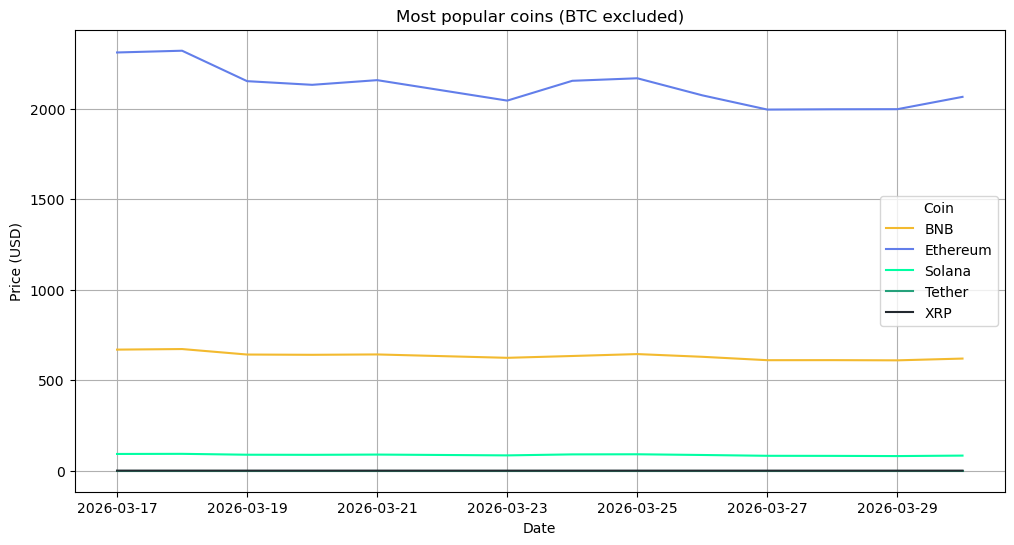

In [12]:
#graph generator
pivot_df.plot(figsize=(12,6), color=["#F3BA2F", "#627EEA", "#00FFA3", "#26A17B", "#23292F"])

plt.title("Most popular coins (BTC excluded)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend(title="Coin")
plt.grid(True)

#log scale for better visibility
#plt.yscale("log")


plt.show()

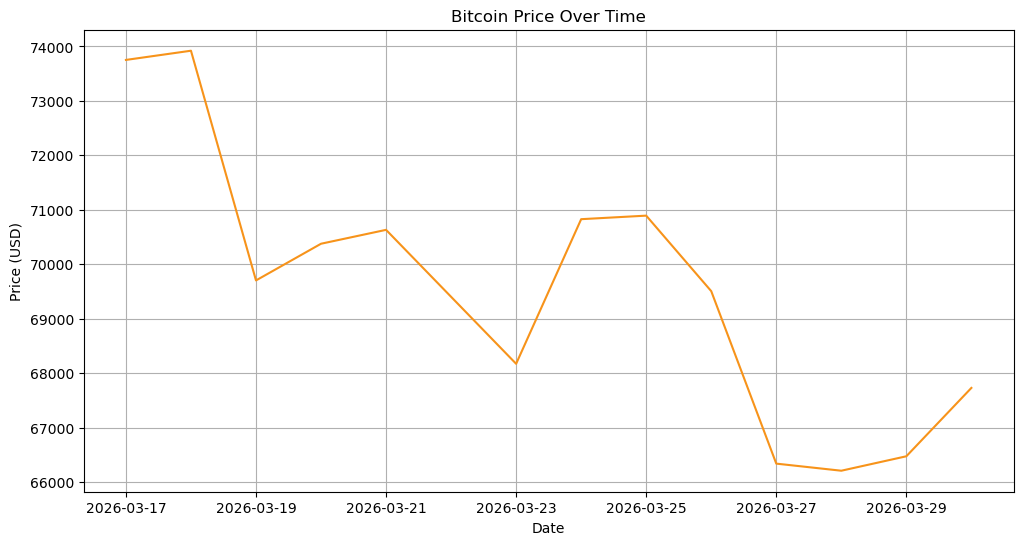

In [13]:
# BTC graph
btc_query = """
SELECT date, name, current_price
FROM crypto_prices_cleaned
WHERE name IN ('Bitcoin')
ORDER BY date;
"""

btc_df = pd.read_sql(btc_query, conn)

# date conversion
btc_df["date"] = pd.to_datetime(btc_df["date"]).dt.date
# getting rid of possible duplicates
btc_df = btc_df.groupby(["date", "name"], as_index=False).mean()
# pivot table
pivot_btc_df = btc_df.pivot(index="date", columns="name", values="current_price")

#graph generator
pivot_btc_df.plot(figsize=(12,6), color="#F7931A", legend=False)

plt.title("Bitcoin Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.grid(True)


plt.show()

In [14]:
conn.close()